In [1]:
import os

# Search for the correct path
print("Searching for APTOS dataset...")
base = "/kaggle/input"

for folder in os.listdir(base):
    print(f"  Found: {folder}")
    subfolder = os.path.join(base, folder)
    for item in os.listdir(subfolder):
        print(f"    - {item}")

Searching for APTOS dataset...
  Found: competitions
    - aptos2019-blindness-detection


In [2]:
from pathlib import Path

TRAIN_CSV = Path("/kaggle/input/competitions/aptos2019-blindness-detection/train.csv")
TRAIN_IMG = Path("/kaggle/input/competitions/aptos2019-blindness-detection/train_images")

print(f"CSV exists   : {TRAIN_CSV.exists()}")
print(f"Images exist : {TRAIN_IMG.exists()}")
print(f"Image count  : {len(list(TRAIN_IMG.glob('*.png')))}")
print("✅ Done!")

CSV exists   : True
Images exist : True
Image count  : 3662
✅ Done!


In [3]:
# ── Install missing packages ───────────────────────────────────
!pip install -q imbalanced-learn
print("✅ Packages ready.")

✅ Packages ready.


In [4]:
import os, random, warnings, gc
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    cohen_kappa_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint,
    ReduceLROnPlateau, CSVLogger
)

warnings.filterwarnings("ignore")

# ════════════════════════════════════════════════════════════
#  CONSTANTS
# ════════════════════════════════════════════════════════════
# ── Updated constants ──────────────────────────────────────────
SEED        = 42
IMG_SIZE    = 300    # ← changed from 224 to 300
BATCH_SIZE  = 16     # ← changed from 32 to 16 (300x300 needs more memory)
NUM_CLASSES = 5
CLASS_NAMES = ["No DR", "Mild", "Moderate",
               "Severe", "Proliferative"]
COLORS      = ["#22c55e", "#84cc16", "#f59e0b",
               "#ef4444", "#7f1d1d"]

# ── Paths (same as before) ─────────────────────────────────────
TRAIN_CSV = Path("/kaggle/input/competitions/"
                 "aptos2019-blindness-detection/train.csv")
TRAIN_IMG = Path("/kaggle/input/competitions/"
                 "aptos2019-blindness-detection/train_images")

OUT         = Path("/kaggle/working")
OUT_MODELS  = OUT / "models"
OUT_PLOTS   = OUT / "plots"
OUT_GRADCAM = OUT / "gradcam"
OUT_LOGS    = OUT / "logs"

for d in [OUT_MODELS, OUT_PLOTS, OUT_GRADCAM, OUT_LOGS]:
    d.mkdir(parents=True, exist_ok=True)

# ── Reproducibility ────────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"]       = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

print("Updated settings:")
print(f"  IMG_SIZE   : {IMG_SIZE}x{IMG_SIZE}  ← 300 now!")
print(f"  BATCH_SIZE : {BATCH_SIZE}           ← 16 now!")
print(f"  NUM_CLASSES: {NUM_CLASSES}")
print(f"  TensorFlow : {tf.__version__}")
print(f"  GPU        : {tf.config.list_physical_devices('GPU')}")
print()
print("✅ Constants updated.")

2026-05-16 11:50:13.471565: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778932213.658035      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778932213.712822      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778932214.186114      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778932214.186148      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778932214.186150      57 computation_placer.cc:177] computation placer alr

Updated settings:
  IMG_SIZE   : 300x300  ← 300 now!
  BATCH_SIZE : 16           ← 16 now!
  NUM_CLASSES: 5
  TensorFlow : 2.19.0
  GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

✅ Constants updated.


In [5]:
# ── Load CSV and build filepath column ────────────────────────
df = pd.read_csv(TRAIN_CSV)
df["filepath"] = df["id_code"].apply(
    lambda x: str(TRAIN_IMG / f"{x}.png")
)

print(f"Total images : {len(df)}")
print()

# ── Class distribution ─────────────────────────────────────────
dist = df["diagnosis"].value_counts().sort_index()
print("Class distribution:")
print(f"{'Grade':<6} {'Name':<18} {'Count':>6}  {'%':>6}")
print("─" * 40)
for grade, count in dist.items():
    pct = count / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"  {grade:<4} {CLASS_NAMES[grade]:<18} "
          f"{count:>6}  {pct:>5.1f}%  {bar}")
print()
print("✅ Dataset reloaded.")

# ── Verify all image files exist ───────────────────────────────
print("Checking image files...")
missing = [
    row["filepath"]
    for _, row in df.iterrows()
    if not os.path.exists(row["filepath"])
]

if len(missing) == 0:
    print(f"✅ All {len(df)} image files verified.")
else:
    print(f"❌ {len(missing)} missing files!")
    for m in missing[:3]:
        print(f"   {m}")

Total images : 3662

Class distribution:
Grade  Name                Count       %
────────────────────────────────────────
  0    No DR                1805   49.3%  ████████████████████████
  1    Mild                  370   10.1%  █████
  2    Moderate              999   27.3%  █████████████
  3    Severe                193    5.3%  ██
  4    Proliferative         295    8.1%  ████

✅ Dataset reloaded.
Checking image files...
✅ All 3662 image files verified.


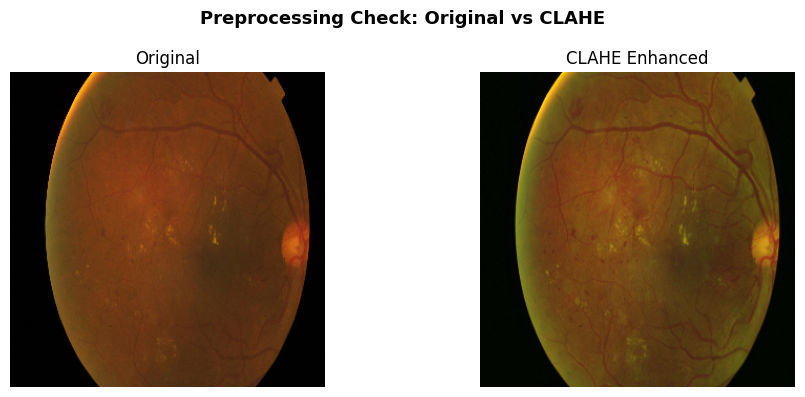

IMG_SIZE    : 300x300
Pixel range : 0.0 to 254.0
Shape       : (300, 300, 3)
Dtype       : float32

✅ Preprocessing functions ready.


In [6]:
#processing funtions
def apply_clahe(bgr_image: np.ndarray) -> np.ndarray:
    """
    Apply CLAHE to GREEN channel only.
    Green channel has highest contrast for retinal
    vessels, microaneurysms and haemorrhages.
    """
    clahe   = cv2.createCLAHE(
        clipLimit=2.0, tileGridSize=(8, 8)
    )
    b, g, r = cv2.split(bgr_image)
    return cv2.merge([b, clahe.apply(g), r])


def preprocess_image(filepath: str,
                     img_size: int = IMG_SIZE
                     ) -> np.ndarray:
    """
    Full preprocessing pipeline for one retinal image.
    Steps: load → resize → CLAHE → BGR→RGB → keep 0-255 range

    IMPORTANT: We keep pixels in 0-255 range (NOT 0-1).
    EfficientNetB3 handles its own internal normalization.
    Dividing by 255 caused the training collapse we saw before.

    Returns: float32 array (img_size, img_size, 3) range 0-255
    """
    img = cv2.imread(filepath)
    if img is None:
        raise FileNotFoundError(
            f"Cannot load: {filepath}"
        )
    img = cv2.resize(
        img, (img_size, img_size),
        interpolation=cv2.INTER_AREA
    )
    img = apply_clahe(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32)  # 0-255, NO division
    return img


# ── Visual check ───────────────────────────────────────────────
test_path = df.iloc[0]["filepath"]

raw = cv2.cvtColor(
    cv2.resize(cv2.imread(test_path), (IMG_SIZE, IMG_SIZE)),
    cv2.COLOR_BGR2RGB
)
enhanced = preprocess_image(test_path)
# Normalize just for display (not for model)
enhanced_display = enhanced / 255.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Preprocessing Check: Original vs CLAHE",
             fontsize=13, fontweight="bold")
axes[0].imshow(raw)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(enhanced_display)
axes[1].set_title("CLAHE Enhanced")
axes[1].axis("off")
plt.tight_layout()
plt.savefig(str(OUT_PLOTS / "01_preprocessing.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# ── Verify pixel range ─────────────────────────────────────────
print(f"IMG_SIZE    : {IMG_SIZE}x{IMG_SIZE}")
print(f"Pixel range : {enhanced.min():.1f}"
      f" to {enhanced.max():.1f}")
print(f"Shape       : {enhanced.shape}")
print(f"Dtype       : {enhanced.dtype}")
print()
print("✅ Preprocessing functions ready.")

In [7]:
# ── Stratified 70/15/15 split ──────────────────────────────────
train_df, temp_df = train_test_split(
    df, test_size=0.30,
    stratify=df["diagnosis"],
    random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    stratify=temp_df["diagnosis"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("Dataset split:")
print(f"  Train : {len(train_df):5d} "
      f"({len(train_df)/len(df)*100:.1f}%)")
print(f"  Val   : {len(val_df):5d} "
      f"({len(val_df)/len(df)*100:.1f}%)")
print(f"  Test  : {len(test_df):5d} "
      f"({len(test_df)/len(df)*100:.1f}%)")
print()

print("Grade distribution per split:")
print(f"{'Grade':<6} {'Name':<18} "
      f"{'Train':>7} {'Val':>7} {'Test':>7}")
print("─" * 48)
for i in range(NUM_CLASSES):
    t  = len(train_df[train_df["diagnosis"] == i])
    v  = len(val_df[val_df["diagnosis"] == i])
    te = len(test_df[test_df["diagnosis"] == i])
    print(f"  {i:<4} {CLASS_NAMES[i]:<18} "
          f"{t:>7} {v:>7} {te:>7}")
print()

# ── Manual class weights (capped at 2.0) ──────────────────────
grade_counts = {
    i: len(train_df[train_df["diagnosis"] == i])
    for i in range(NUM_CLASSES)
}
max_count = max(grade_counts.values())

class_weights = {}
for i in range(NUM_CLASSES):
    raw_w = max_count / grade_counts[i]
    class_weights[i] = round(min(raw_w, 2.0), 4)

print("Class weights (capped at 2.0):")
for i, w in class_weights.items():
    bar = "█" * int(w * 10)
    print(f"  Grade {i} ({CLASS_NAMES[i]:<15}): "
          f"{w:.4f}  {bar}")
print()
print("✅ Split and class weights ready.")

Dataset split:
  Train :  2563 (70.0%)
  Val   :   549 (15.0%)
  Test  :   550 (15.0%)

Grade distribution per split:
Grade  Name                 Train     Val    Test
────────────────────────────────────────────────
  0    No DR                 1263     271     271
  1    Mild                   259      55      56
  2    Moderate               699     150     150
  3    Severe                 135      29      29
  4    Proliferative          207      44      44

Class weights (capped at 2.0):
  Grade 0 (No DR          ): 1.0000  ██████████
  Grade 1 (Mild           ): 2.0000  ████████████████████
  Grade 2 (Moderate       ): 1.8069  ██████████████████
  Grade 3 (Severe         ): 2.0000  ████████████████████
  Grade 4 (Proliferative  ): 2.0000  ████████████████████

✅ Split and class weights ready.


In [8]:
#7. oversampling
from imblearn.over_sampling import RandomOverSampler

print("Before oversampling:")
for i in range(NUM_CLASSES):
    count = len(train_df[train_df["diagnosis"] == i])
    print(f"  Grade {i} ({CLASS_NAMES[i]:<15}): {count:5d}")

# ── Oversample minority classes ────────────────────────────────
ros   = RandomOverSampler(random_state=SEED)
X_idx = train_df.index.values.reshape(-1, 1)
y_idx = train_df["diagnosis"].values

X_res, y_res = ros.fit_resample(X_idx, y_idx)

# Rebuild balanced train_df
train_df_bal = train_df.iloc[
    X_res.flatten()
].reset_index(drop=True)

# Shuffle after oversampling — prevents grade clustering
train_df_bal = train_df_bal.sample(
    frac=1, random_state=SEED
).reset_index(drop=True)

print("\nAfter oversampling + shuffle:")
for i in range(NUM_CLASSES):
    count = len(
        train_df_bal[train_df_bal["diagnosis"] == i]
    )
    print(f"  Grade {i} ({CLASS_NAMES[i]:<15}): {count:5d}")

print(f"\nTotal train samples : {len(train_df_bal)}")

print(f"\nFirst 10 grades (should be mixed):")
print(train_df_bal["diagnosis"].head(10).tolist())
print()
print("✅ Oversampling done.")

Before oversampling:
  Grade 0 (No DR          ):  1263
  Grade 1 (Mild           ):   259
  Grade 2 (Moderate       ):   699
  Grade 3 (Severe         ):   135
  Grade 4 (Proliferative  ):   207

After oversampling + shuffle:
  Grade 0 (No DR          ):  1263
  Grade 1 (Mild           ):  1263
  Grade 2 (Moderate       ):  1263
  Grade 3 (Severe         ):  1263
  Grade 4 (Proliferative  ):  1263

Total train samples : 6315

First 10 grades (should be mixed):
[0, 2, 3, 3, 1, 0, 1, 4, 2, 1]

✅ Oversampling done.


In [9]:
#tf pipeline 300 x 300
def tf_load(filepath: tf.Tensor,
            label: tf.Tensor):
    """
    Load image — pixels kept at 0-255 range.
    300x300 now instead of 224x224.
    """
    raw   = tf.io.read_file(filepath)
    image = tf.image.decode_png(raw, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    # NO division by 255!
    label = tf.one_hot(
        tf.cast(label, tf.int32), NUM_CLASSES
    )
    return image, label


def tf_augment(image: tf.Tensor,
               label: tf.Tensor):
    """
    Augmentation for 0-255 range images.
    Slightly stronger than before to help
    with 300x300 variety.
    """
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(
        image, max_delta=25.5
    )
    image = tf.image.random_contrast(
        image, lower=0.8, upper=1.2
    )
    image = tf.image.random_saturation(
        image, lower=0.9, upper=1.1
    )
    image = tf.image.random_hue(
        image, max_delta=0.05  # ← new! subtle hue shift
    )
    image = tf.clip_by_value(image, 0.0, 255.0)
    return image, label


def build_dataset(
    dataframe:  pd.DataFrame,
    augment:    bool = False,
    shuffle:    bool = False
) -> tf.data.Dataset:
    """Build prefetched batched tf.data.Dataset."""
    paths  = dataframe["filepath"].values
    labels = dataframe["diagnosis"].astype(
        np.int32
    ).values

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        tf_load,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if augment:
        ds = ds.map(
            tf_augment,
            num_parallel_calls=tf.data.AUTOTUNE
        )

    return ds.batch(BATCH_SIZE).prefetch(
        tf.data.AUTOTUNE
    )


# ── Build all three datasets ───────────────────────────────────
# Train uses oversampled balanced data
train_ds = build_dataset(
    train_df_bal, augment=True,  shuffle=True
)
val_ds   = build_dataset(
    val_df,       augment=False, shuffle=False
)
test_ds  = build_dataset(
    test_df,      augment=False, shuffle=False
)

# ── Verify everything ──────────────────────────────────────────
print("Verifying pipeline...")
for imgs, lbls in train_ds.take(1):
    print(f"Image shape : {imgs.shape}")
    print(f"Label shape : {lbls.shape}")
    print(f"Pixel range : {imgs.numpy().min():.1f}"
          f" to {imgs.numpy().max():.1f}"
          f"  (must be 0 to ~255)")
    print(f"First 5 labels (should be mixed):")
    for i in range(5):
        g = np.argmax(lbls[i].numpy())
        print(f"  Sample {i}: Grade {g}"
              f" ({CLASS_NAMES[g]})")

print()
print(f"Train batches : {len(train_ds)}")
print(f"Val   batches : {len(val_ds)}")
print(f"Test  batches : {len(test_ds)}")
print()
print("✅ tf.data pipeline ready.")

I0000 00:00:1778932245.927936      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778932245.933813      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Verifying pipeline...
Image shape : (16, 300, 300, 3)
Label shape : (16, 5)
Pixel range : 0.0 to 255.0  (must be 0 to ~255)
First 5 labels (should be mixed):
  Sample 0: Grade 0 (No DR)
  Sample 1: Grade 3 (Severe)
  Sample 2: Grade 2 (Moderate)
  Sample 3: Grade 4 (Proliferative)
  Sample 4: Grade 4 (Proliferative)

Train batches : 395
Val   batches : 35
Test  batches : 35

✅ tf.data pipeline ready.


In [10]:
# ── Focal Loss function ────────────────────────────────────────
def focal_loss(gamma: float = 2.0,
               alpha: float = 0.25):
    """
    Focal Loss — designed for imbalanced classification.

    How it works:
    - Easy examples (model already confident) → small loss
    - Hard examples (model uncertain) → large loss

    This forces the model to focus on difficult grades
    like Grade 3 (Severe) instead of just getting
    easy Grade 0 correct.

    gamma : focusing parameter
            0.0 = same as crossentropy
            2.0 = standard focal loss (recommended)
    alpha : weight factor (0.25 is standard)
    """
    def loss_fn(y_true, y_pred):
        # Clip predictions to prevent log(0)
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0)

        # Standard cross entropy
        ce = -y_true * tf.math.log(y_pred)

        # Probability of correct class
        pt = tf.reduce_sum(
            y_true * y_pred, axis=-1, keepdims=True
        )

        # Focal weight — down-weights easy examples
        focal_weight = alpha * tf.pow(1.0 - pt, gamma)

        # Final focal loss
        loss = focal_weight * ce
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

    return loss_fn
    
# build model
def build_model(learning_rate: float = 1e-4):
    """
    EfficientNetB3 transfer learning model.

    Architecture:
      Input (300x300x3)
      → EfficientNetB3 [ImageNet, frozen Stage 1]
      → GlobalAveragePooling2D
      → BatchNormalization
      → Dropout(0.4)
      → Dense(256, relu)
      → Dropout(0.2)
      → Dense(5, softmax)

    Note: EfficientNetB3 receives 0-255 pixels
    and handles its own normalization internally.
    """
    # Base backbone — frozen for Stage 1
    base = EfficientNetB3(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False

    # Custom classification head
    inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(256, activation="relu")(x)
    x       = layers.Dropout(0.2)(x)
    outputs = layers.Dense(
        NUM_CLASSES, activation="softmax"
    )(x)

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="DR_EfficientNetB3_FocalLoss"
    )

   # Compile with Focal Loss instead of crossentropy
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=["accuracy"]
    )
    return model, base


# ── Build fresh model ──────────────────────────────────────────
gc.collect()
tf.keras.backend.clear_session()

model, base_model = build_model(learning_rate=1e-4)

# Parameter summary
total     = model.count_params()
trainable = sum(
    tf.size(w).numpy()
    for w in model.trainable_weights
)
frozen = total - trainable

print("Model built with Focal Loss!")
print()
print(f"  Loss function: Focal Loss (gamma=2.0)")
print(f"  Input size   : {IMG_SIZE}x{IMG_SIZE}")
print(f"  Total params : {total:>12,}")
print(f"  Trainable    : {trainable:>12,}")
print(f"  Frozen       : {frozen:>12,}")
print()

# Sanity check
for imgs, lbls in val_ds.take(1):
    preds = model(imgs, training=False)
    print("Fresh model predictions (should be ~0.20):")
    for i, p in enumerate(preds[0].numpy()):
        bar = "█" * int(p * 50)
        print(f"  Grade {i} ({CLASS_NAMES[i]:<15}): "
              f"{p:.4f}")
    print(f"  Sum : {preds[0].numpy().sum():.4f}"
          f"  (must be 1.0)")

print()
print("✅ Model ready for training.")

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model built with Focal Loss!

  Loss function: Focal Loss (gamma=2.0)
  Input size   : 300x300
  Total params :   11,184,436
  Trainable    :      397,829
  Frozen       :   10,786,607



I0000 00:00:1778932253.695521      57 cuda_dnn.cc:529] Loaded cuDNN version 91002


Fresh model predictions (should be ~0.20):
  Grade 0 (No DR          ): 0.2026
  Grade 1 (Mild           ): 0.2869
  Grade 2 (Moderate       ): 0.1587
  Grade 3 (Severe         ): 0.1283
  Grade 4 (Proliferative  ): 0.2235
  Sum : 1.0000  (must be 1.0)

✅ Model ready for training.


In [11]:
#stage 1 training
# ── Callbacks ──────────────────────────────────────────────────
CKPT_PATH = str(OUT_MODELS / "best_model.keras")

callbacks_s1 = [
    ModelCheckpoint(
        filepath=CKPT_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-8,
        verbose=1
    ),
    CSVLogger(
        str(OUT_LOGS / "training_log.csv"),
        append=False
    )
]

print("=" * 55)
print("  STAGE 1 — Head only (base FROZEN)")
print(f"  Loss       : Focal Loss (gamma=2.0) ← new!")
print(f"  LR         : 1e-4")
print(f"  IMG size   : {IMG_SIZE}x{IMG_SIZE}  ← bigger!")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  Max epochs : 25              ← more!")
print(f"  Train size : {len(train_df_bal)} (oversampled)")
print("=" * 55)
print()

history_s1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weights,
    callbacks=callbacks_s1,
    verbose=1
)

# ── Prediction check ───────────────────────────────────────────
print("\n── Prediction check after Stage 1 ──")
y_val_prob = model.predict(val_ds, verbose=0)
y_val_pred = np.argmax(y_val_prob, axis=1)
y_val_true = val_df["diagnosis"].values

print("Prediction distribution:")
unique, counts = np.unique(y_val_pred, return_counts=True)
for g, c in zip(unique, counts):
    print(f"  Grade {g} ({CLASS_NAMES[g]:<15}): "
          f"{c:4d} ({c/len(y_val_pred)*100:.1f}%)")

s1_acc = np.mean(y_val_pred == y_val_true)
print(f"\nVal accuracy : {s1_acc:.4f}")
print(f"Best val acc : "
      f"{max(history_s1.history['val_accuracy']):.4f}")
print()
print("✅ Stage 1 complete.")

  STAGE 1 — Head only (base FROZEN)
  Loss       : Focal Loss (gamma=2.0) ← new!
  LR         : 1e-4
  IMG size   : 300x300  ← bigger!
  Batch size : 16
  Max epochs : 25              ← more!
  Train size : 6315 (oversampled)

Epoch 1/25


E0000 00:00:1778932269.586282      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/DR_EfficientNetB3_FocalLoss_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.3890 - loss: 0.5707
Epoch 1: val_accuracy improved from -inf to 0.69399, saving model to /kaggle/working/models/best_model.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 271s 637ms/step - accuracy: 0.3892 - loss: 0.5704 - val_accuracy: 0.6940 - val_loss: 0.1044 - learning_rate: 1.0000e-04
Epoch 2/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.5404 - loss: 0.3571
Epoch 2: val_accuracy improved from 0.69399 to 0.73588, saving model to /kaggle/working/models/best_model.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 240s 606ms/step - accuracy: 0.5404 - loss: 0.3571 - val_accuracy: 0.7359 - val_loss: 0.0992 - learning_rate: 1.0000e-04
Epoch 3/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.5963 - loss: 0.2998
Epoch 3: val_accuracy did not improve from 0.73588
395/395 ━━━━━━━━━━━━━━━━━━━━ 239s 604ms/step - accuracy: 0.5963 - loss: 0.2997 - val_accuracy: 0.7250 - val_loss: 0.0980 - learning_rate: 1.0000e-04
Epoch 4/25
395/395 ━━━━━━━━━

In [12]:
# ── Backup Stage 1 model first ─────────────────────────────────
import shutil
shutil.copy(
    str(OUT_MODELS / "best_model.keras"),
    str(OUT_MODELS / "best_model_stage1.keras")
)
print("✅ Stage 1 model backed up!")
print(f"   Val accuracy: 0.7614")

✅ Stage 1 model backed up!
   Val accuracy: 0.7614


In [13]:
#stage 2 fine tuning

# ── Unfreeze top 30 layers ─────────────────────────────────────
print("Unfreezing top 30 layers...")
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_now = sum(
    tf.size(w).numpy()
    for w in model.trainable_weights
)
print(f"Trainable params now: {trainable_now:,}")
print(f"Was 397,829 in Stage 1")
print()

# Recompile with Focal Loss at lower LR
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=["accuracy"]
)
print("Recompiled with LR=1e-5 + Focal Loss")

# ── Callbacks ──────────────────────────────────────────────────
callbacks_s2 = [
    ModelCheckpoint(
        filepath=CKPT_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-9,
        verbose=1
    ),
    CSVLogger(
        str(OUT_LOGS / "training_log.csv"),
        append=True
    )
]

print()
print("=" * 55)
print("  STAGE 2 — Fine-tuning top 30 layers")
print(f"  Loss       : Focal Loss (gamma=2.0)")
print(f"  LR         : 1e-5  (10x lower)")
print(f"  Max epochs : 30    (more room)")
print(f"  Starting   : val_acc=0.7614")
print("=" * 55)
print()

history_s2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks_s2,
    verbose=1
)

# ── Prediction check ───────────────────────────────────────────
print("\n── Prediction check after Stage 2 ──")
y_val_prob = model.predict(val_ds, verbose=0)
y_val_pred = np.argmax(y_val_prob, axis=1)
y_val_true = val_df["diagnosis"].values

print("Prediction distribution:")
unique, counts = np.unique(y_val_pred, return_counts=True)
for g, c in zip(unique, counts):
    print(f"  Grade {g} ({CLASS_NAMES[g]:<15}): "
          f"{c:4d} ({c/len(y_val_pred)*100:.1f}%)")

s2_acc = np.mean(y_val_pred == y_val_true)
print(f"\nVal accuracy : {s2_acc:.4f}")
print(f"Best val acc : "
      f"{max(history_s2.history['val_accuracy']):.4f}")
print()
print("✅ Stage 2 complete.")

Unfreezing top 30 layers...
Trainable params now: 3,951,999
Was 397,829 in Stage 1

Recompiled with LR=1e-5 + Focal Loss

  STAGE 2 — Fine-tuning top 30 layers
  Loss       : Focal Loss (gamma=2.0)
  LR         : 1e-5  (10x lower)
  Max epochs : 30    (more room)
  Starting   : val_acc=0.7614

Epoch 1/30


E0000 00:00:1778935454.378444      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/DR_EfficientNetB3_FocalLoss_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.4938 - loss: 0.3738
Epoch 1: val_accuracy improved from -inf to 0.71949, saving model to /kaggle/working/models/best_model.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 262s 616ms/step - accuracy: 0.4938 - loss: 0.3737 - val_accuracy: 0.7195 - val_loss: 0.1171 - learning_rate: 1.0000e-05
Epoch 2/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.5799 - loss: 0.3072
Epoch 2: val_accuracy improved from 0.71949 to 0.72860, saving model to /kaggle/working/models/best_model.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 239s 605ms/step - accuracy: 0.5799 - loss: 0.3072 - val_accuracy: 0.7286 - val_loss: 0.1114 - learning_rate: 1.0000e-05
Epoch 3/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.5793 - loss: 0.2972
Epoch 3: val_accuracy improved from 0.72860 to 0.74499, saving model to /kaggle/working/models/best_model.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 240s 606ms/step - accuracy: 0.5794 - loss: 0.2972 - val_accuracy: 0.7450 - val_loss: 0.

In [14]:
# ── Load best model ────────────────────────────────────────────
CKPT_PATH  = str(OUT_MODELS / "best_model.keras")
best_model = keras.models.load_model(
    CKPT_PATH,
    custom_objects={"loss_fn": focal_loss(
        gamma=2.0, alpha=0.25
    )}
)
print(f"✅ Model loaded: {CKPT_PATH}")

# ── Predict on test set ────────────────────────────────────────
print("\nRunning predictions on test set...")
y_prob = best_model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_df["diagnosis"].values

# ── Core metrics ───────────────────────────────────────────────
accuracy = np.mean(y_pred == y_true)
qwk      = cohen_kappa_score(
    y_true, y_pred, weights="quadratic"
)

print()
print("=" * 50)
print("   FINAL TEST SET RESULTS")
print("=" * 50)
print(f"  Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  QWK Score : {qwk:.4f}  (target ≥ 0.80)")
print("=" * 50)
print()

# ── Classification report ──────────────────────────────────────
print("Classification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    digits=4
))

# ── Prediction distribution ────────────────────────────────────
print("Prediction distribution on test set:")
unique, counts = np.unique(y_pred, return_counts=True)
for g, c in zip(unique, counts):
    pct = c / len(y_pred) * 100
    bar = "█" * int(pct / 2)
    print(f"  Grade {g} ({CLASS_NAMES[g]:<15}): "
          f"{c:4d} ({pct:5.1f}%)  {bar}")
print()

# ── Compare with previous run ──────────────────────────────────
print("=" * 50)
print("   COMPARISON WITH PREVIOUS RUN")
print("=" * 50)
print(f"  Previous QWK  : 0.8446")
print(f"  Current  QWK  : {qwk:.4f}")
print(f"  Difference    : {qwk - 0.8446:+.4f}")
print()
print(f"  Previous Acc  : 0.7545")
print(f"  Current  Acc  : {accuracy:.4f}")
print(f"  Difference    : {accuracy - 0.7545:+.4f}")
print("=" * 50)

# ── Save report ────────────────────────────────────────────────
report_text = "\n".join([
    "=" * 50,
    "DIABETIC RETINOPATHY — EVALUATION REPORT",
    "=" * 50,
    f"Model      : EfficientNetB3 + Focal Loss",
    f"Dataset    : APTOS 2019",
    f"IMG size   : {IMG_SIZE}x{IMG_SIZE}",
    f"Test size  : {len(y_true)} samples",
    f"",
    f"RESULTS:",
    f"  Accuracy  : {accuracy:.4f}",
    f"  QWK Score : {qwk:.4f}",
    f"",
    "CLASSIFICATION REPORT:",
    classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        digits=4
    )
])

report_path = str(OUT / "evaluation_report.txt")
with open(report_path, "w") as f:
    f.write(report_text)
print(f"✅ Report saved!")

✅ Model loaded: /kaggle/working/models/best_model.keras

Running predictions on test set...
35/35 ━━━━━━━━━━━━━━━━━━━━ 22s 529ms/step

   FINAL TEST SET RESULTS
  Accuracy  : 0.7655 (76.55%)
  QWK Score : 0.8501  (target ≥ 0.80)

Classification Report:
               precision    recall  f1-score   support

        No DR     0.9669    0.9705    0.9687       271
         Mild     0.4868    0.6607    0.5606        56
     Moderate     0.7583    0.6067    0.6741       150
       Severe     0.3077    0.4138    0.3529        29
Proliferative     0.4186    0.4091    0.4138        44

     accuracy                         0.7655       550
    macro avg     0.5877    0.6121    0.5940       550
 weighted avg     0.7825    0.7655    0.7699       550

Prediction distribution on test set:
  Grade 0 (No DR          ):  272 ( 49.5%)  ████████████████████████
  Grade 1 (Mild           ):   76 ( 13.8%)  ██████
  Grade 2 (Moderate       ):  120 ( 21.8%)  ██████████
  Grade 3 (Severe         ):   39 (  

In [15]:
# ── TTA — predict each image 5 times ──────────────────────────
def tta_predict(model, dataset, n_augments=5):
    """
    Test Time Augmentation.

    Instead of predicting each image once,
    we predict it N times with slight random
    augmentations and average the probabilities.

    This gives more stable predictions because:
    - Single prediction can be unlucky
    - Average of 5 predictions is more reliable
    """
    all_probs = []

    for i in range(n_augments):
        print(f"  TTA round {i+1}/{n_augments}...")
        round_probs = []

        for imgs, _ in dataset:
            # Apply slight augmentation
            imgs_aug = imgs

            # Random horizontal flip (50% chance)
            if tf.random.uniform(()) > 0.5:
                imgs_aug = tf.image.flip_left_right(imgs_aug)

            # Random brightness shift
            imgs_aug = tf.image.random_brightness(
                imgs_aug, max_delta=15.0
            )
            imgs_aug = tf.clip_by_value(
                imgs_aug, 0.0, 255.0
            )

            # Predict
            probs = model(imgs_aug, training=False)
            round_probs.append(probs.numpy())

        all_probs.append(
            np.concatenate(round_probs, axis=0)
        )

    # Average all rounds
    avg_probs = np.mean(all_probs, axis=0)
    return avg_probs


print("Running TTA (5 rounds)...")
print("Each round predicts all 550 test images")
print()

# Run TTA
y_prob_tta = tta_predict(
    best_model, test_ds, n_augments=5
)
y_pred_tta = np.argmax(y_prob_tta, axis=1)

# ── Compare results ────────────────────────────────────────────
accuracy_tta = np.mean(y_pred_tta == y_true)
qwk_tta      = cohen_kappa_score(
    y_true, y_pred_tta, weights="quadratic"
)

print()
print("=" * 50)
print("   TTA RESULTS")
print("=" * 50)
print(f"  Accuracy  : {accuracy_tta:.4f} "
      f"({accuracy_tta*100:.2f}%)")
print(f"  QWK Score : {qwk_tta:.4f}")
print("=" * 50)
print()

# Compare
print("Comparison:")
print(f"  Without TTA: acc={accuracy:.4f}  "
      f"QWK={qwk:.4f}")
print(f"  With TTA   : acc={accuracy_tta:.4f}  "
      f"QWK={qwk_tta:.4f}")
print(f"  Difference : acc={accuracy_tta-accuracy:+.4f}  "
      f"QWK={qwk_tta-qwk:+.4f}")
print()

# Classification report
print("Classification Report with TTA:")
print(classification_report(
    y_true, y_pred_tta,
    target_names=CLASS_NAMES,
    digits=4
))
print("✅ TTA complete.")

Running TTA (5 rounds)...
Each round predicts all 550 test images

  TTA round 1/5...
  TTA round 2/5...
  TTA round 3/5...
  TTA round 4/5...
  TTA round 5/5...

   TTA RESULTS
  Accuracy  : 0.7600 (76.00%)
  QWK Score : 0.8477

Comparison:
  Without TTA: acc=0.7655  QWK=0.8501
  With TTA   : acc=0.7600  QWK=0.8477
  Difference : acc=-0.0055  QWK=-0.0024

Classification Report with TTA:
               precision    recall  f1-score   support

        No DR     0.9670    0.9742    0.9706       271
         Mild     0.4483    0.6964    0.5455        56
     Moderate     0.7736    0.5467    0.6406       150
       Severe     0.3243    0.4138    0.3636        29
Proliferative     0.4468    0.4773    0.4615        44

     accuracy                         0.7600       550
    macro avg     0.5920    0.6217    0.5964       550
 weighted avg     0.7859    0.7600    0.7646       550

✅ TTA complete.


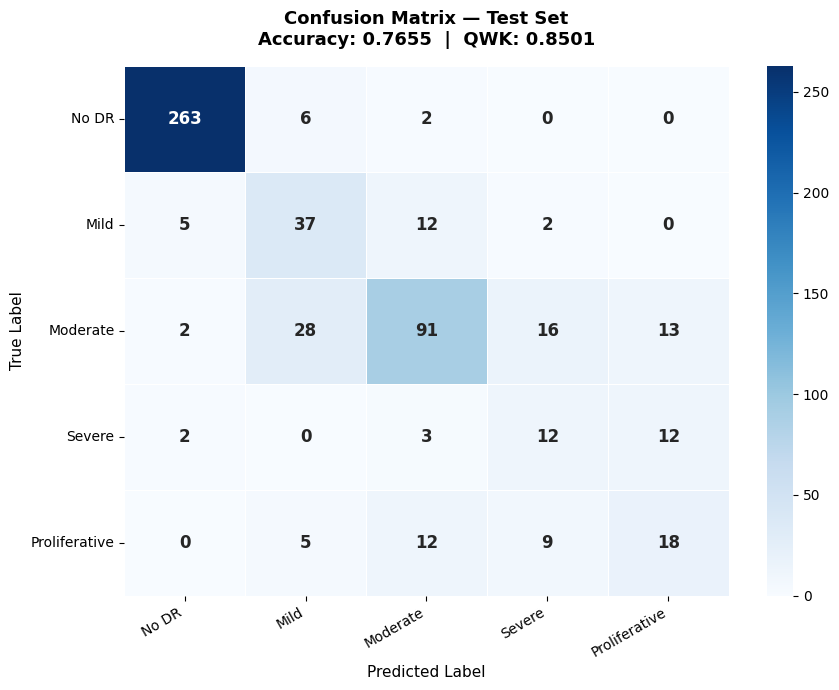

✅ Saved: 02_confusion_matrix.png


In [16]:
# ── Confusion Matrix ───────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5,
    annot_kws={"size": 12, "weight": "bold"}
)
ax.set_title(
    f"Confusion Matrix — Test Set\n"
    f"Accuracy: {accuracy:.4f}  |  "
    f"QWK: {qwk:.4f}",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_ylabel("True Label", fontsize=11)
ax.set_xlabel("Predicted Label", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(
    str(OUT_PLOTS / "02_confusion_matrix.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()
print("✅ Saved: 02_confusion_matrix.png")

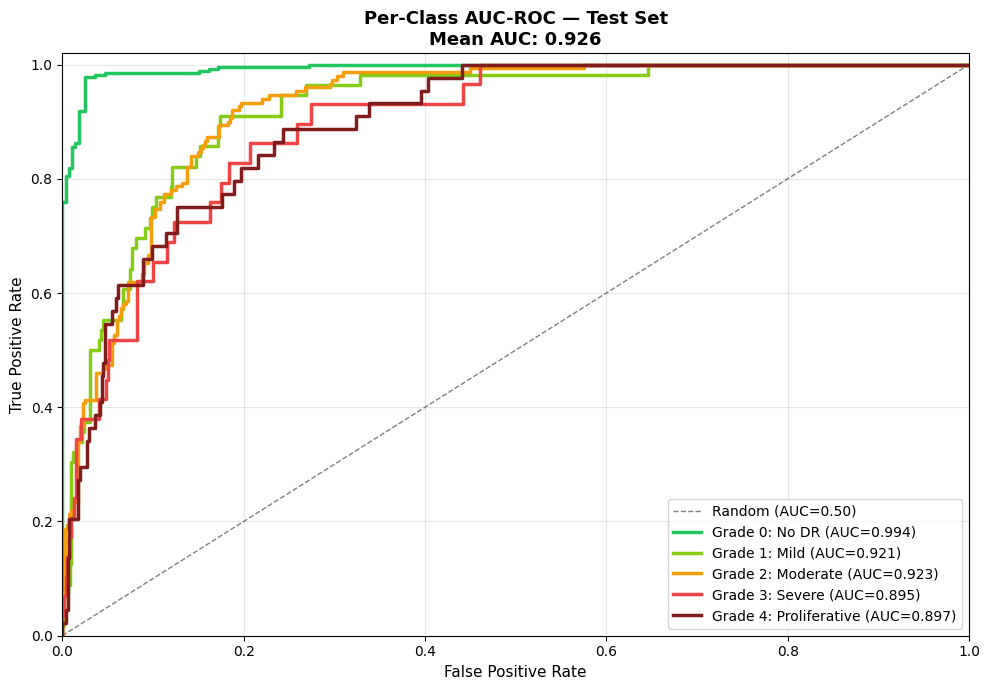

AUC scores per grade:
  Grade 0 (No DR          ): 0.9937  ███████████████████
  Grade 1 (Mild           ): 0.9210  ██████████████████
  Grade 2 (Moderate       ): 0.9227  ██████████████████
  Grade 3 (Severe         ): 0.8948  █████████████████
  Grade 4 (Proliferative  ): 0.8969  █████████████████

  Mean AUC : 0.9258

✅ Saved: 03_auc_roc.png


In [17]:
# ── AUC-ROC Curves ─────────────────────────────────────────────
y_true_bin = label_binarize(
    y_true, classes=list(range(NUM_CLASSES))
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(
    [0, 1], [0, 1],
    "k--", lw=1, alpha=0.5,
    label="Random (AUC=0.50)"
)

auc_scores = []
for i, (name, color) in enumerate(
    zip(CLASS_NAMES, COLORS)
):
    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i], y_prob[:, i]
    )
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    ax.plot(
        fpr, tpr,
        color=color, lw=2.5,
        label=f"Grade {i}: {name} "
              f"(AUC={roc_auc:.3f})"
    )

ax.set_title(
    f"Per-Class AUC-ROC — Test Set\n"
    f"Mean AUC: {np.mean(auc_scores):.3f}",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(
    str(OUT_PLOTS / "03_auc_roc.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()

print("AUC scores per grade:")
for i, (name, score) in enumerate(
    zip(CLASS_NAMES, auc_scores)
):
    bar = "█" * int(score * 20)
    print(f"  Grade {i} ({name:<15}): "
          f"{score:.4f}  {bar}")
print(f"\n  Mean AUC : {np.mean(auc_scores):.4f}")
print()
print("✅ Saved: 03_auc_roc.png")

Generating Grad-CAM visualizations...
2 samples per grade = 10 images total

Grade 0 — No DR (2 samples)


2026-05-16 13:55:38.734961: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  Sample 1: True=No DR           Pred=No DR           [CORRECT]


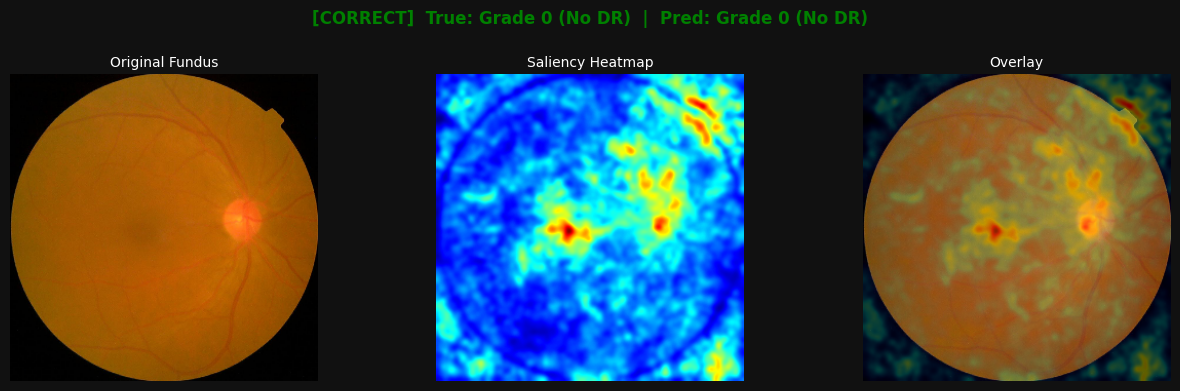

2026-05-16 13:55:44.090178: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  Sample 2: True=No DR           Pred=No DR           [CORRECT]


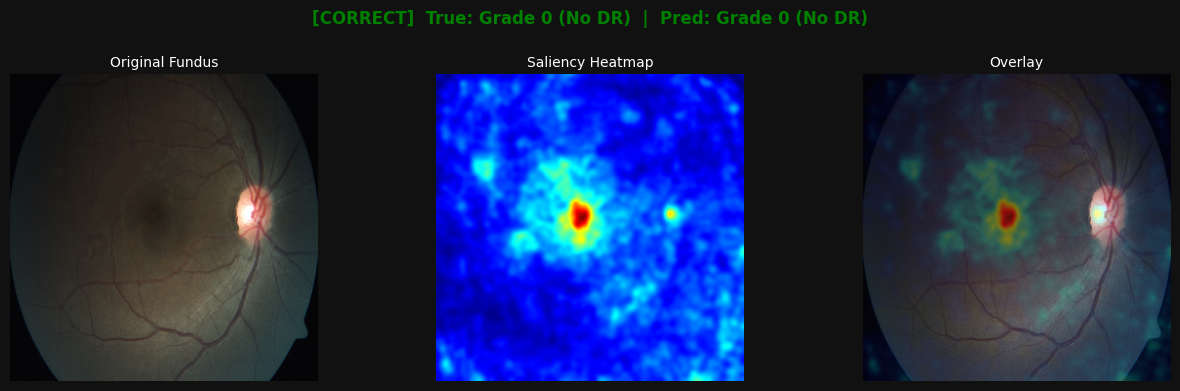


Grade 1 — Mild (2 samples)
  Sample 1: True=Mild            Pred=Proliferative   [WRONG → Grade 4]


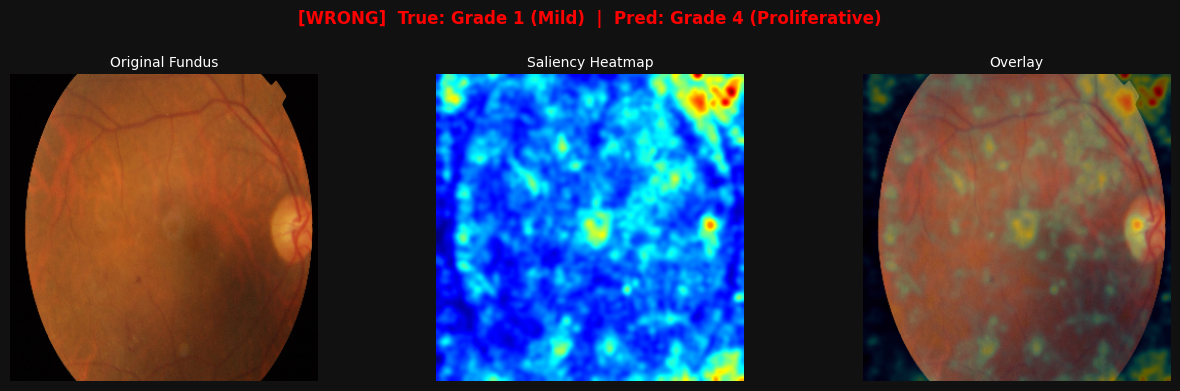

  Sample 2: True=Mild            Pred=Proliferative   [WRONG → Grade 4]


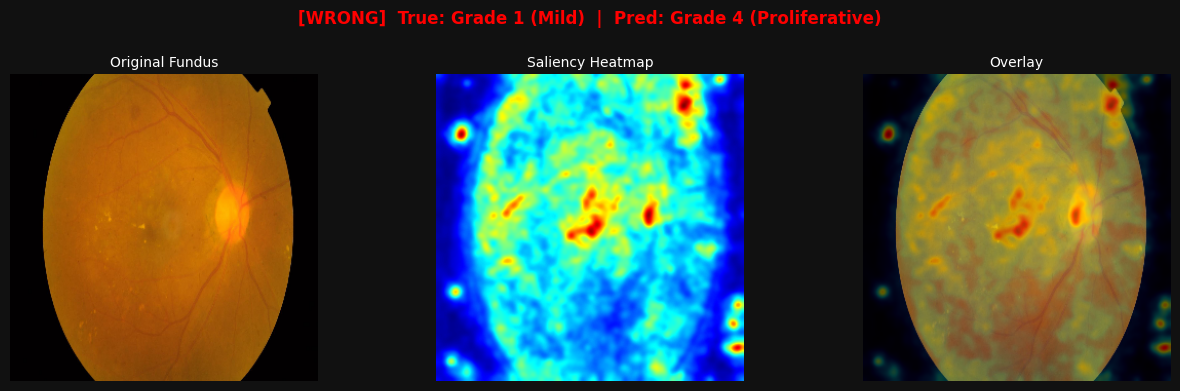


Grade 2 — Moderate (2 samples)


2026-05-16 13:55:50.014991: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  Sample 1: True=Moderate        Pred=Proliferative   [WRONG → Grade 4]


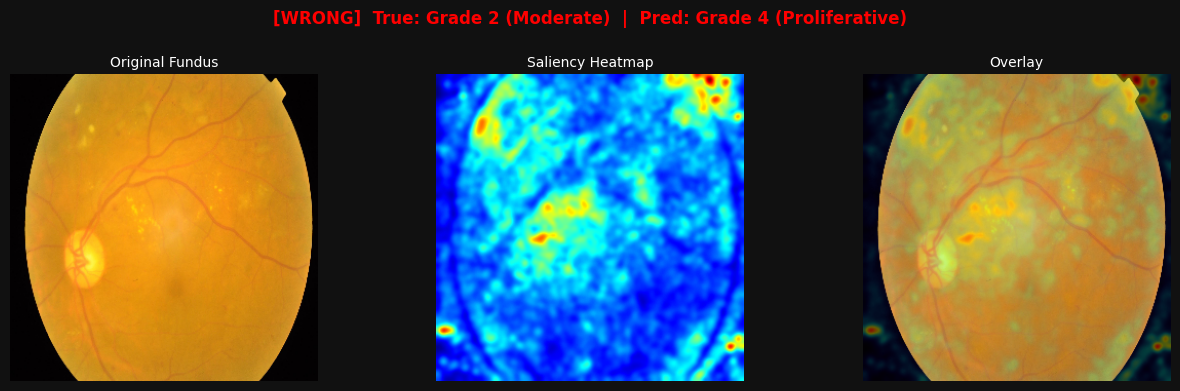

  Sample 2: True=Moderate        Pred=Severe          [WRONG → Grade 3]


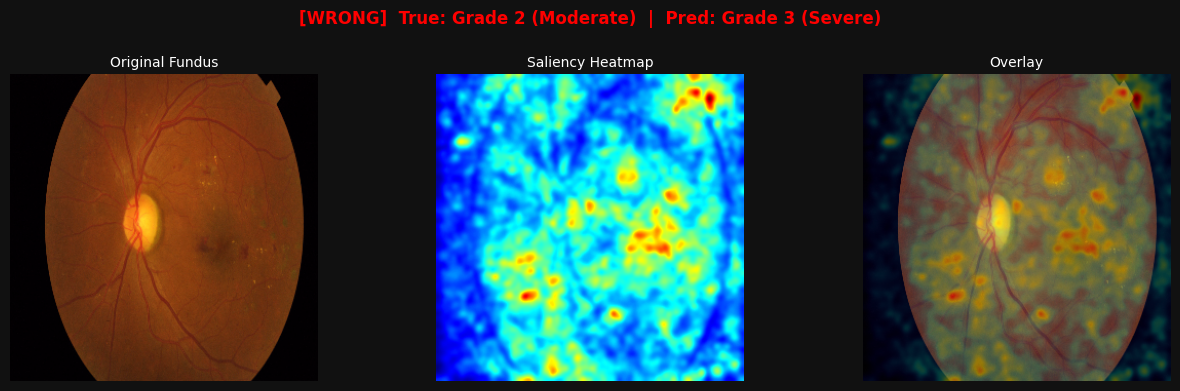


Grade 3 — Severe (2 samples)
  Sample 1: True=Severe          Pred=Severe          [CORRECT]


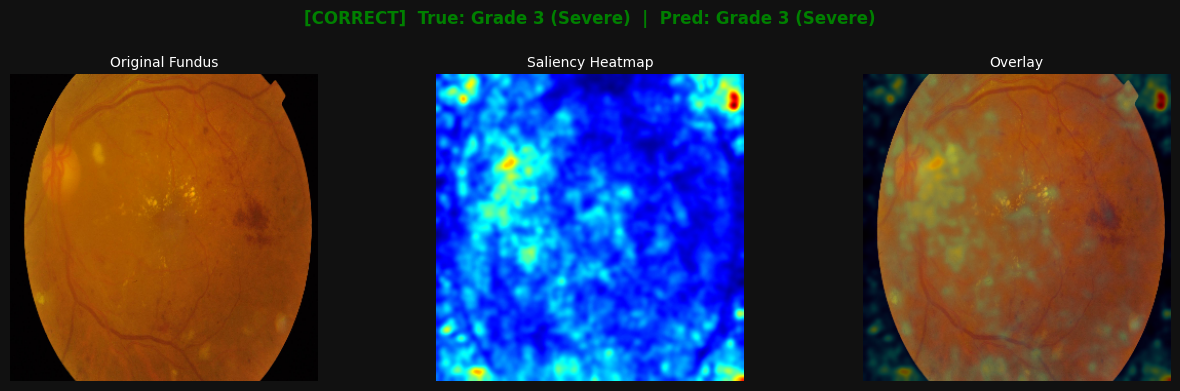

2026-05-16 13:55:57.075593: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  Sample 2: True=Severe          Pred=Severe          [CORRECT]


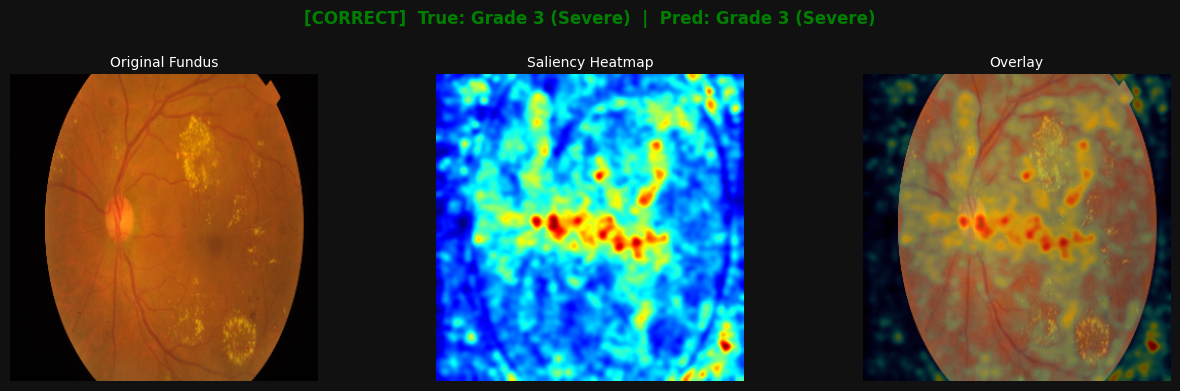


Grade 4 — Proliferative (2 samples)
  Sample 1: True=Proliferative   Pred=Proliferative   [CORRECT]


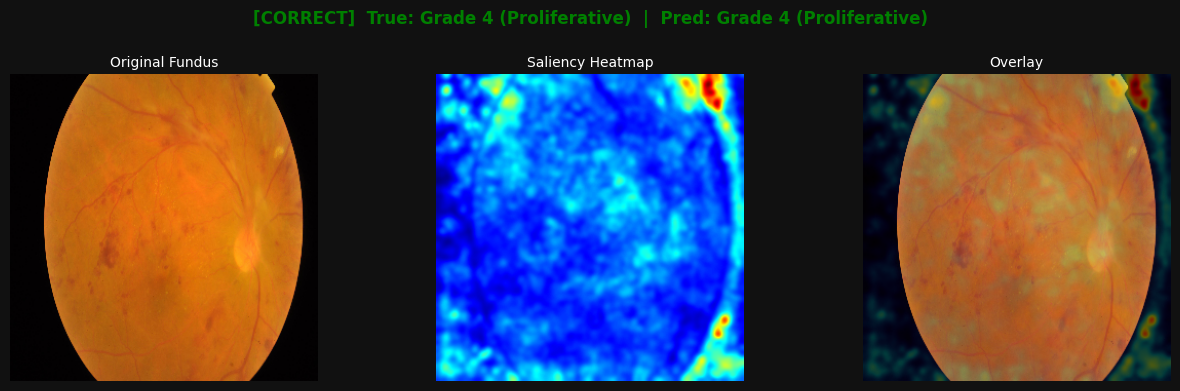

  Sample 2: True=Proliferative   Pred=Severe          [WRONG → Grade 3]


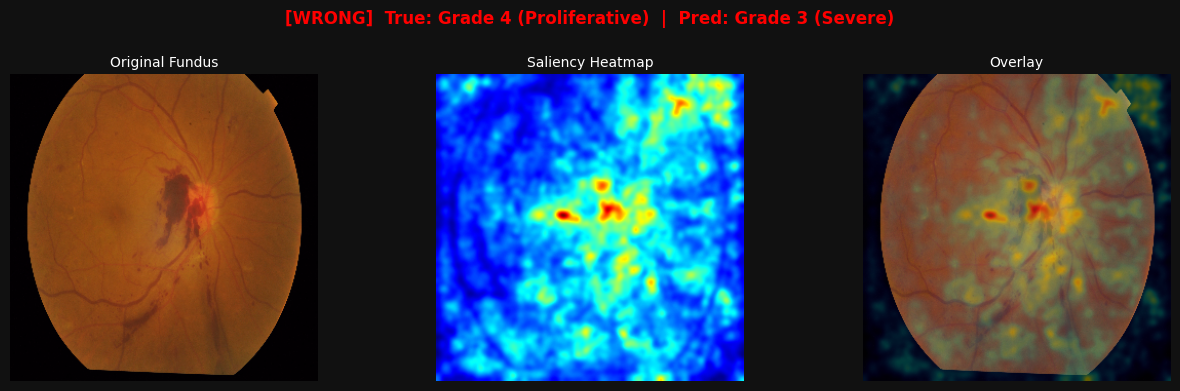


Grad-CAM complete!
Correct: 5/10 on these samples
Saved to: /kaggle/working/gradcam


In [18]:
# ── Grad-CAM function ──────────────────────────────────────────
def make_gradcam(img_path: str,
                 true_grade: int,
                 pred_grade: int,
                 save_path: str) -> None:
    """
    Input-gradient saliency heatmap.
    Pure TensorFlow — works with all versions.
    Shows which retinal regions influenced prediction.
    """
    # Prepare display image
    img_display = cv2.cvtColor(
        cv2.resize(
            cv2.imread(img_path),
            (IMG_SIZE, IMG_SIZE)
        ),
        cv2.COLOR_BGR2RGB
    )

    # Prepare model input
    img_input  = preprocess_image(img_path)
    img_tensor = tf.Variable(
        img_input[np.newaxis, ...],
        dtype=tf.float32
    )

    # Compute gradients
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        preds = best_model(
            img_tensor, training=False
        )
        score = preds[:, pred_grade]

    grads = tape.gradient(
        score, img_tensor
    ).numpy()[0]

    # Build heatmap from squared gradients
    heatmap = np.sum(grads ** 2, axis=-1)
    heatmap = np.sqrt(heatmap)
    heatmap = cv2.GaussianBlur(
        heatmap, (15, 15), 0
    )
    heatmap = np.power(heatmap, 0.5)
    heatmap = (
        heatmap - heatmap.min()
    ) / (heatmap.max() - heatmap.min() + 1e-8)

    # Colorize
    h_uint8 = np.uint8(255 * heatmap)
    heatmap_color = cv2.cvtColor(
        cv2.applyColorMap(
            h_uint8, cv2.COLORMAP_JET
        ),
        cv2.COLOR_BGR2RGB
    )

    # Blend with original
    alpha   = heatmap[:, :, np.newaxis]
    overlay = np.clip(
        (1 - alpha * 0.6) *
        img_display.astype(float) +
        (alpha * 0.6) *
        heatmap_color.astype(float),
        0, 255
    ).astype(np.uint8)

    # Plot
    correct     = "CORRECT" if true_grade == pred_grade \
                  else "WRONG"
    label_color = "green" if true_grade == pred_grade \
                  else "red"

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    fig.patch.set_facecolor("#111111")
    fig.suptitle(
        f"[{correct}]  "
        f"True: Grade {true_grade} "
        f"({CLASS_NAMES[true_grade]})  |  "
        f"Pred: Grade {pred_grade} "
        f"({CLASS_NAMES[pred_grade]})",
        fontsize=12, fontweight="bold",
        color=label_color
    )
    for ax, im, title in zip(
        axes,
        [img_display, heatmap_color, overlay],
        ["Original Fundus",
         "Saliency Heatmap",
         "Overlay"]
    ):
        ax.imshow(im)
        ax.set_title(
            title, fontsize=10,
            color="white", pad=5
        )
        ax.axis("off")

    plt.tight_layout(pad=1.5)
    plt.savefig(
        save_path, dpi=130,
        bbox_inches="tight",
        facecolor=fig.get_facecolor()
    )
    plt.show()
    plt.close()


# ── Generate 2 Grad-CAM images per grade ──────────────────────
print("Generating Grad-CAM visualizations...")
print("2 samples per grade = 10 images total\n")

results = []
for grade in range(NUM_CLASSES):
    samples = test_df[
        test_df["diagnosis"] == grade
    ].head(2)

    print(f"Grade {grade} — "
          f"{CLASS_NAMES[grade]} "
          f"({len(samples)} samples)")

    if len(samples) == 0:
        print(f"  No samples — skipping")
        continue

    for n, (_, row) in enumerate(
        samples.iterrows(), start=1
    ):
        # Get prediction
        inp = preprocess_image(
            row["filepath"]
        )[np.newaxis, ...]
        pred_probs = best_model.predict(
            inp, verbose=0
        )
        pred_grade = int(np.argmax(pred_probs))

        save_path = str(
            OUT_GRADCAM /
            f"gradcam_grade{grade}_sample{n}.png"
        )

        status = "CORRECT" \
            if pred_grade == grade \
            else f"WRONG → Grade {pred_grade}"

        print(f"  Sample {n}: "
              f"True={CLASS_NAMES[grade]:<15} "
              f"Pred={CLASS_NAMES[pred_grade]:<15}"
              f" [{status}]")

        make_gradcam(
            row["filepath"],
            grade,
            pred_grade,
            save_path
        )
        results.append({
            "true"   : grade,
            "pred"   : pred_grade,
            "correct": pred_grade == grade
        })
    print()

# ── Summary ────────────────────────────────────────────────────
correct_count = sum(
    1 for r in results if r["correct"]
)
print("=" * 45)
print(f"Grad-CAM complete!")
print(f"Correct: {correct_count}/{len(results)}"
      f" on these samples")
print(f"Saved to: {OUT_GRADCAM}")
print("=" * 45)

In [19]:
# ── Check all files saved ──────────────────────────────────────
print("Files saved in /kaggle/working:")
print()

total_size = 0
for folder in [OUT_MODELS, OUT_PLOTS,
               OUT_GRADCAM, OUT_LOGS, OUT]:
    files = [f for f in Path(folder).iterdir()
             if f.is_file()]
    if files:
        print(f"📁 {folder.name}/")
        for f in sorted(files):
            size_kb = f.stat().st_size / 1024
            total_size += size_kb
            print(f"   📄 {f.name:<45} "
                  f"{size_kb:>8.1f} KB")
        print()

print(f"Total size: {total_size/1024:.1f} MB")

Files saved in /kaggle/working:

📁 models/
   📄 best_model.keras                               75915.8 KB
   📄 best_model_stage1.keras                        48129.1 KB

📁 plots/
   📄 01_preprocessing.png                             491.0 KB
   📄 02_confusion_matrix.png                           77.1 KB
   📄 03_auc_roc.png                                   112.2 KB

📁 gradcam/
   📄 gradcam_grade0_sample1.png                       568.2 KB
   📄 gradcam_grade0_sample2.png                       549.6 KB
   📄 gradcam_grade1_sample1.png                       579.3 KB
   📄 gradcam_grade1_sample2.png                       506.2 KB
   📄 gradcam_grade2_sample1.png                       572.5 KB
   📄 gradcam_grade2_sample2.png                       625.2 KB
   📄 gradcam_grade3_sample1.png                       554.6 KB
   📄 gradcam_grade3_sample2.png                       604.5 KB
   📄 gradcam_grade4_sample1.png                       538.4 KB
   📄 gradcam_grade4_sample2.png                      

In [23]:
# ── Zip everything and download ────────────────────────────────
import shutil
from IPython.display import FileLink

print("Creating zip file...")

# Zip all outputs
shutil.make_archive(
    "/kaggle/working/dr_project_complete",
    "zip",
    "/kaggle/working"
)

zip_size = Path(
    "/kaggle/working/dr_project_complete.zip"
).stat().st_size / (1024*1024)

print(f"✅ Zip created: {zip_size:.1f} MB")
print()
print("Click the link below to download:")
display(FileLink(
    "/kaggle/working/dr_project_complete.zip"
))

Creating zip file...
✅ Zip created: 115.6 MB

Click the link below to download:


/kaggle/working/dr_project_complete.zip

In [24]:
# ── Save version to make files permanent ──────────────────────
# On Kaggle, files only persist if you Save a Version

print("Important: To keep files after session ends:")
print()
print("1. Click 'Save Version' button (top right)")
print("2. Choose 'Save & Run All'")
print("3. After it finishes → Output tab → download")
print()
print("OR download right now from Output panel:")
print("Right panel → Output → /kaggle/working/")
print()

# List all downloadable files
import os
print("Files available to download:")
for root, dirs, files in os.walk("/kaggle/working"):
    # Skip the zip to avoid confusion
    for file in files:
        if not file.endswith(".zip"):
            filepath = os.path.join(root, file)
            size_mb = os.path.getsize(filepath) / (1024*1024)
            rel_path = filepath.replace(
                "/kaggle/working/", ""
            )
            print(f"  {rel_path:<50} {size_mb:.1f} MB")

Important: To keep files after session ends:

1. Click 'Save Version' button (top right)
2. Choose 'Save & Run All'
3. After it finishes → Output tab → download

OR download right now from Output panel:
Right panel → Output → /kaggle/working/

Files available to download:
  evaluation_report.txt                              0.0 MB
  .virtual_documents/__notebook_source__.ipynb       0.0 MB
  gradcam/gradcam_grade0_sample2.png                 0.5 MB
  gradcam/gradcam_grade4_sample1.png                 0.5 MB
  gradcam/gradcam_grade2_sample2.png                 0.6 MB
  gradcam/gradcam_grade3_sample1.png                 0.5 MB
  gradcam/gradcam_grade0_sample1.png                 0.6 MB
  gradcam/gradcam_grade3_sample2.png                 0.6 MB
  gradcam/gradcam_grade1_sample1.png                 0.6 MB
  gradcam/gradcam_grade2_sample1.png                 0.6 MB
  gradcam/gradcam_grade4_sample2.png                 0.6 MB
  gradcam/gradcam_grade1_sample2.png                 0.5 MB
  plots

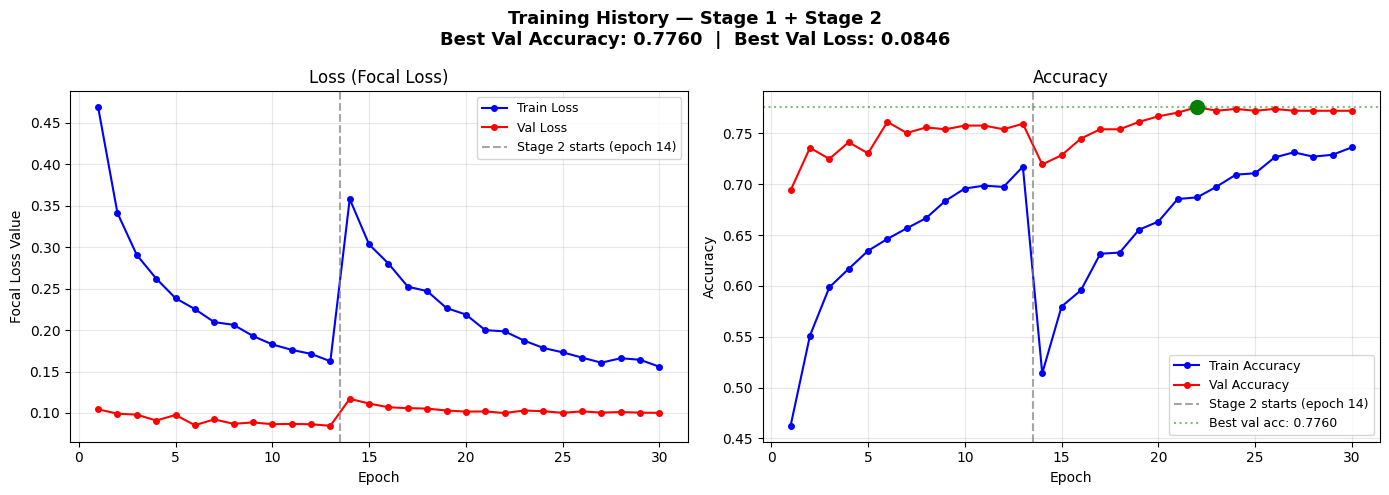

✅ Saved: 04_training_curves.png

Training Summary:
  Stage 1 epochs   : 13
  Stage 2 epochs   : 17
  Total epochs     : 30

  Best val accuracy: 0.7760 (epoch 22)
  Best val loss    : 0.0846

  Final train acc  : 0.7363
  Final val acc    : 0.7723
  Overfitting gap  : -0.0360


In [22]:
# ── Plot training curves ───────────────────────────────────────
# Combine Stage 1 + Stage 2 history
def plot_training_curves(h1, h2):
    """
    Plot combined Stage 1 + Stage 2 training curves.
    Shows loss and accuracy for both train and val.
    """
    # Combine histories
    train_loss = (h1.history["loss"] +
                  h2.history["loss"])
    val_loss   = (h1.history["val_loss"] +
                  h2.history["val_loss"])
    train_acc  = (h1.history["accuracy"] +
                  h2.history["accuracy"])
    val_acc    = (h1.history["val_accuracy"] +
                  h2.history["val_accuracy"])

    epochs     = range(1, len(train_loss) + 1)
    s1_end     = len(h1.history["loss"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        "Training History — Stage 1 + Stage 2\n"
        f"Best Val Accuracy: "
        f"{max(val_acc):.4f}  |  "
        f"Best Val Loss: "
        f"{min(val_loss):.4f}",
        fontsize=13, fontweight="bold"
    )

    # ── Loss plot ──────────────────────────────────
    axes[0].plot(
        epochs, train_loss,
        "b-o", ms=4, lw=1.5,
        label="Train Loss"
    )
    axes[0].plot(
        epochs, val_loss,
        "r-o", ms=4, lw=1.5,
        label="Val Loss"
    )
    axes[0].axvline(
        s1_end + 0.5,
        color="gray",
        linestyle="--",
        alpha=0.7,
        label=f"Stage 2 starts (epoch {s1_end+1})"
    )
    axes[0].set_title(
        "Loss (Focal Loss)",
        fontsize=12
    )
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Focal Loss Value")
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    # ── Accuracy plot ──────────────────────────────
    axes[1].plot(
        epochs, train_acc,
        "b-o", ms=4, lw=1.5,
        label="Train Accuracy"
    )
    axes[1].plot(
        epochs, val_acc,
        "r-o", ms=4, lw=1.5,
        label="Val Accuracy"
    )
    axes[1].axvline(
        s1_end + 0.5,
        color="gray",
        linestyle="--",
        alpha=0.7,
        label=f"Stage 2 starts (epoch {s1_end+1})"
    )
    # Mark best val accuracy
    best_epoch = val_acc.index(max(val_acc)) + 1
    best_acc   = max(val_acc)
    axes[1].axhline(
        best_acc,
        color="green",
        linestyle=":",
        alpha=0.5,
        label=f"Best val acc: {best_acc:.4f}"
    )
    axes[1].scatter(
        best_epoch, best_acc,
        color="green", s=100,
        zorder=5
    )
    axes[1].set_title(
        "Accuracy",
        fontsize=12
    )
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        str(OUT_PLOTS / "04_training_curves.png"),
        dpi=150, bbox_inches="tight"
    )
    plt.show()
    print("✅ Saved: 04_training_curves.png")

    # ── Print summary ──────────────────────────────
    print()
    print("Training Summary:")
    print(f"  Stage 1 epochs   : "
          f"{len(h1.history['loss'])}")
    print(f"  Stage 2 epochs   : "
          f"{len(h2.history['loss'])}")
    print(f"  Total epochs     : {len(train_loss)}")
    print()
    print(f"  Best val accuracy: {max(val_acc):.4f} "
          f"(epoch {best_epoch})")
    print(f"  Best val loss    : {min(val_loss):.4f}")
    print()
    print(f"  Final train acc  : "
          f"{train_acc[-1]:.4f}")
    print(f"  Final val acc    : "
          f"{val_acc[-1]:.4f}")
    print(f"  Overfitting gap  : "
          f"{train_acc[-1] - val_acc[-1]:.4f}")


# Run the plot
plot_training_curves(history_s1, history_s2)